# Step 1: Statistical Analysis and Outlier Discovery
Identifying missing values ​​in the data, statistical distribution, and outliers using the IQR (Interquartile Range) method.

--- Veri Seti Temel İstatistikleri ---


,count,mean,std,min,25%,50%,75%,max
application_year,10000.0,2022.371600,2.237636,2019.000000,2020.000000,2022.000000,2024.000000,2026.00
age,10000.0,23.030000,1.895273,20.000000,22.000000,23.000000,24.000000,32.00
graduation_year,10000.0,2022.170100,2.275540,2018.000000,2020.000000,2022.000000,2024.000000,2026.00
cgpa,10000.0,3.074501,0.403068,2.000000,2.790000,3.070000,3.360000,4.00
english_exam_score,9047.0,57.372187,18.698209,2.690000,43.705000,58.120000,71.775000,99.11
attendance_rate,10000.0,81.905727,9.692353,43.700000,75.300000,82.055000,88.832500,100.00
failed_courses_count,10000.0,1.203700,1.094133,0.000000,0.000000,1.000000,2.000000,8.00
coding_score,10000.0,70.580805,13.461120,20.000000,61.770000,70.825000,79.712500,100.00
problem_solving_score,10000.0,71.521592,13.660875,20.000000,62.380000,71.790000,80.870000,100.00
data_structures_score,10000.0,68.453985,13.908858,20.000000,59.370000,68.630000,77.922500,100.00



--- Eksik Veri Analizi (Sadece eksik olanlar) ---
english_exam_score                 953
internship_duration_months        1657
portfolio_score                    364
github_avg_stars                   910
open_source_contribution_count     910
linkedin_profile_score             668
hr_interview_score                 780
dtype: int64

--- Kolonlara Göre Aykırı Değer Sayıları ---


,Outlier Count
feedback_sentiment_communication,3940
feedback_sentiment_teamwork,3684
feedback_sentiment_database_and_cloud,2946
feedback_sentiment_web_development,2798
feedback_sentiment_problem_solving,2793
hackathon_awards,1855
feedback_sentiment_leadership,1374
feedback_sentiment_data_structures,1040
github_avg_stars,450
applications_sent,416


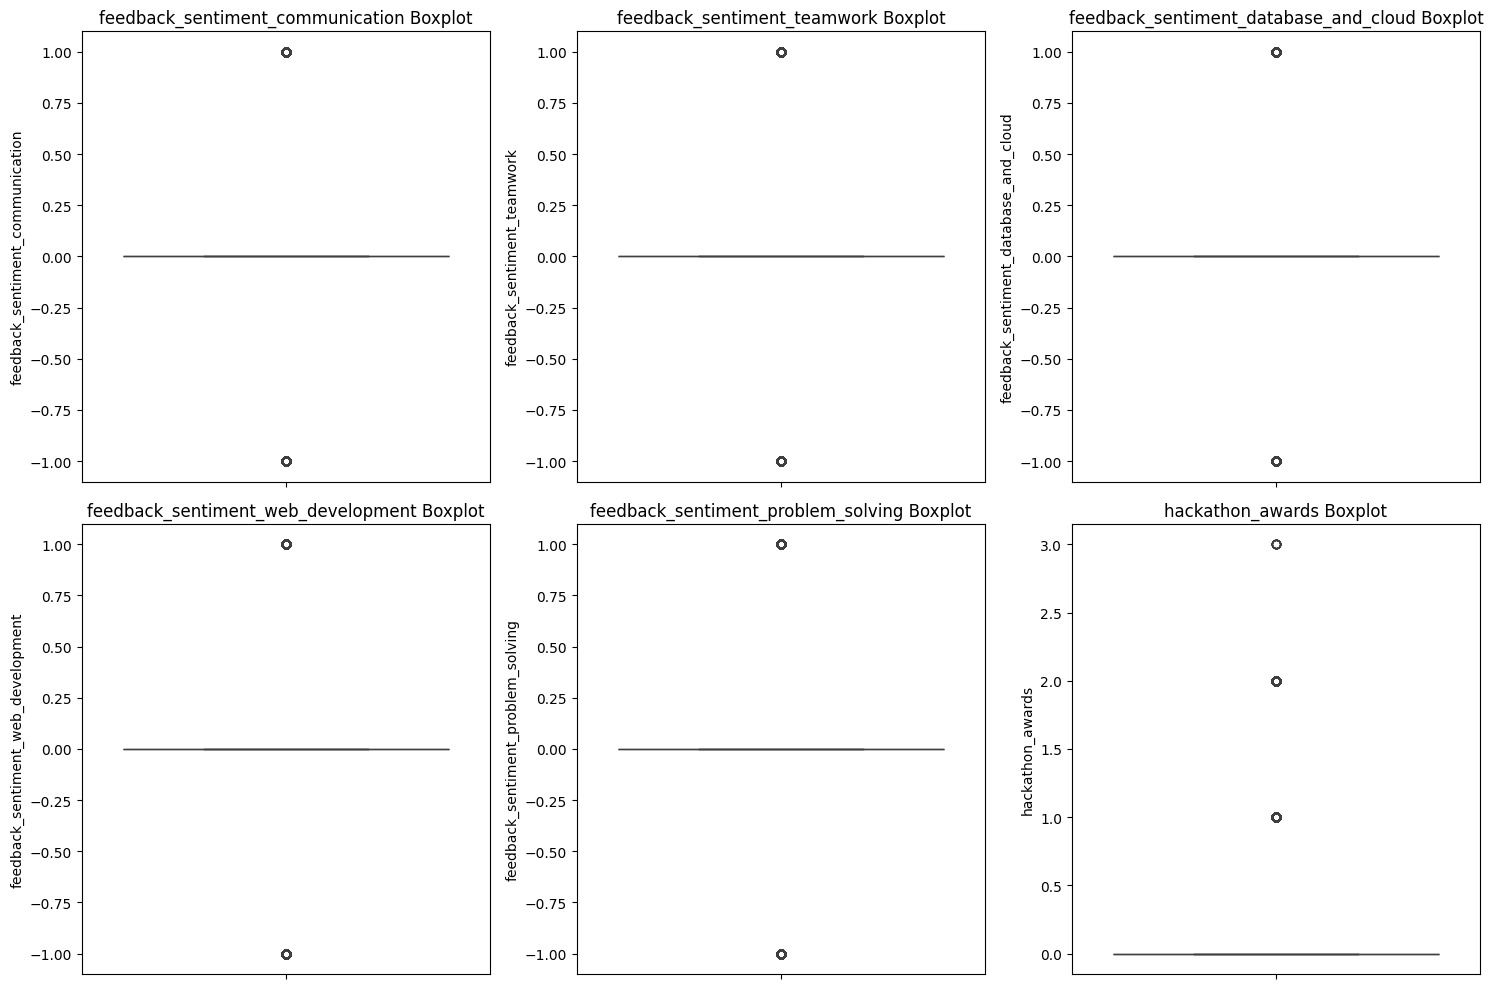

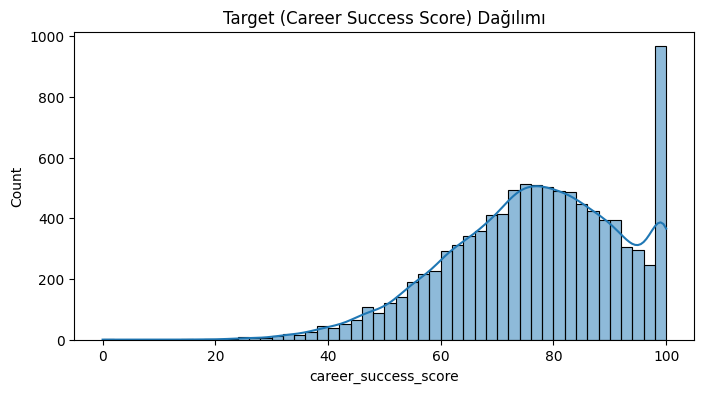

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veriyi Yükleme
train_df = pd.read_csv("data/train_df_with_nlp.csv")
test_df = pd.read_csv("data/test_df_with_nlp.csv")

TARGET = 'career_success_score'

# 2. Temel İstatistiksel Özet
print("--- Veri Seti Temel İstatistikleri ---")
display(train_df.describe().T)

print("\n--- Eksik Veri Analizi (Sadece eksik olanlar) ---")
missing_data = train_df.isnull().sum()
print(missing_data[missing_data > 0])

# 3. IQR Yöntemi ile Aykırı Değer (Outlier) Analizi
def detect_outliers_iqr(df, features):
    outlier_summary = {}
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Aykırı değerlerin sayısını bulma
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_summary[col] = len(outliers)
        
    return pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count']).sort_values(by='Outlier Count', ascending=False)

# Sadece nümerik kolonları seçelim (ID ve Target hariç)
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.drop(['application_year', 'graduation_year', TARGET], errors='ignore')

outliers_df = detect_outliers_iqr(train_df, num_cols)
print("\n--- Kolonlara Göre Aykırı Değer Sayıları ---")
display(outliers_df[outliers_df['Outlier Count'] > 0])

# 4. Aykırı Değerleri Görselleştirme (En çok outlier olan ilk 6 kolon)
top_outlier_cols = outliers_df.head(6).index.tolist()
plt.figure(figsize=(15, 10))
for i, col in enumerate(top_outlier_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=train_df[col])
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()

# Hedef Değişkenin Dağılımı (RMSE yüksekliğinin bir nedeni de target dağılımı olabilir)
plt.figure(figsize=(8, 4))
sns.histplot(train_df[TARGET], kde=True, bins=50)
plt.title('Target (Career Success Score) Dağılımı')
plt.show()

# Step 2: Scaling and Regular Pipeline Setup
- Instead of directly deleting outliers after observing them (which leads to data loss), RobustScaler was used.
- RobustScaler uses the median instead of the mean and IQR instead of the variance; this allows it to scale without being affected by outliers.
- First fill the missing values
- Add new features

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [7]:
def fill_missing_values(train: pd.DataFrame, test: pd.DataFrame):
    train = train.copy()
    test = test.copy()

    mean_cols = ["english_exam_score", "linkedin_profile_score", "hr_interview_score", "portfolio_score"]
    median_cols = ["github_avg_stars", "open_source_contribution_count"]

    for col in mean_cols:
        if col in train.columns:
            fill_value = train[col].mean()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    for col in median_cols:
        if col in train.columns:
            fill_value = train[col].median()
            train[col] = train[col].fillna(fill_value)
            test[col] = test[col].fillna(fill_value)

    col = "internship_duration_months"
    group_col = "internship_count"

    if col in train.columns and group_col in train.columns:
        global_median = train[col].median()
        group_medians = train.groupby(group_col)[col].median()

        train[col] = train.apply(
            lambda row: group_medians.get(row[group_col], global_median) if pd.isna(row[col]) else row[col], axis=1
        )
        test[col] = test.apply(
            lambda row: group_medians.get(row[group_col], global_median) if pd.isna(row[col]) else row[col], axis=1
        )

        train[col] = train[col].fillna(global_median)
        test[col] = test[col].fillna(global_median)

    return train, test

In [9]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ------------------------------------------------------------
    # Graduation / temporal
    # ------------------------------------------------------------
    df["years_since_graduation"] = df["application_year"] - df["graduation_year"]
    df["age_at_graduation"] = df["age"] - df["years_since_graduation"]

    # university_tier kategorik olarak kalır; ayrıca ordinal rank da eklenir.
    tier_rank_map = {
        "Tier 1": 4,
        "Tier 2": 3,
        "Tier 3": 2,
        "Tier 4": 1
    }
    if "university_tier" in df.columns:
        df["university_tier_rank"] = (
            df["university_tier"].map(tier_rank_map).fillna(0).astype(int)
        )

    # ------------------------------------------------------------
    # Technical skill summaries
    # ------------------------------------------------------------
    technical_skill_cols = [
        "coding_score",
        "problem_solving_score",
        "data_structures_score",
        "sql_score",
        "machine_learning_score",
        "backend_score",
        "frontend_score",
        "cloud_score",
        "devops_score"
    ]

    df["technical_skill_mean"] = df[technical_skill_cols].mean(axis=1)
    df["technical_skill_std"] = df[technical_skill_cols].std(axis=1)
    df["technical_skill_min"] = df[technical_skill_cols].min(axis=1)
    df["technical_skill_max"] = df[technical_skill_cols].max(axis=1)
    df["technical_skill_range"] = (
        df["technical_skill_max"] - df["technical_skill_min"]
    )

    df["data_ai_score"] = df[
        [
            "sql_score",
            "machine_learning_score",
            "problem_solving_score",
            "data_structures_score",
            "coding_score"
        ]
    ].mean(axis=1)

    df["software_engineering_score"] = df[
        [
            "backend_score",
            "frontend_score",
            "cloud_score",
            "devops_score",
            "coding_score",
            "data_structures_score"
        ]
    ].mean(axis=1)

    df["cloud_devops_score"] = df[
        ["cloud_score", "devops_score", "backend_score"]
    ].mean(axis=1)

    df["core_cs_score"] = df[
        ["coding_score", "problem_solving_score", "data_structures_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Role-specific skill fit
    # ------------------------------------------------------------
    role = df["target_role"].fillna("").astype(str).str.lower()

    df["role_skill_fit_score"] = df["technical_skill_mean"]

    role_score_specs = [
        (role.eq("backend developer"), ["backend_score", "coding_score", "data_structures_score", "problem_solving_score"]),
        (role.eq("frontend developer"), ["frontend_score", "coding_score", "presentation_score"]),
        (role.eq("software developer"), ["coding_score", "data_structures_score", "problem_solving_score", "backend_score", "frontend_score"]),
        (role.eq("data scientist"), ["machine_learning_score", "sql_score", "problem_solving_score", "data_structures_score", "coding_score"]),
        (role.eq("data analyst"), ["sql_score", "problem_solving_score", "machine_learning_score", "presentation_score"]),
        (role.eq("ai engineer"), ["machine_learning_score", "coding_score", "problem_solving_score", "data_structures_score", "cloud_score"]),
        (role.eq("mlops engineer"), ["machine_learning_score", "devops_score", "cloud_score", "coding_score"]),
        (role.eq("cloud engineer"), ["cloud_score", "devops_score", "backend_score"]),
        (role.eq("devops engineer"), ["devops_score", "cloud_score", "backend_score"]),
        (role.eq("cybersecurity analyst"), ["problem_solving_score", "backend_score", "devops_score", "cloud_score"]),
        (role.eq("product analyst"), ["sql_score", "presentation_score", "communication_score", "problem_solving_score"]),
    ]

    for mask, cols in role_score_specs:
        df.loc[mask, "role_skill_fit_score"] = df.loc[mask, cols].mean(axis=1)

    df["role_fit_minus_technical_mean"] = (
        df["role_skill_fit_score"] - df["technical_skill_mean"]
    )

    # ------------------------------------------------------------
    # Soft skills
    # ------------------------------------------------------------
    soft_skill_cols = [
        "communication_score",
        "teamwork_score",
        "leadership_score",
        "presentation_score",
        "linkedin_profile_score",
        "cv_quality_score",
        "hr_interview_score"
    ]

    df["soft_skill_mean"] = df[soft_skill_cols].mean(axis=1)
    df["soft_skill_std"] = df[soft_skill_cols].std(axis=1)
    df["communication_presentation_mean"] = df[
        ["communication_score", "presentation_score"]
    ].mean(axis=1)

    # ------------------------------------------------------------
    # Project / portfolio / GitHub
    # ------------------------------------------------------------
    df["project_count_total"] = (
        df["real_client_project_count"] + df["freelance_project_count"]
    )

    df["portfolio_project_quality_mean"] = df[
        ["portfolio_score", "project_quality_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_project_quality_interaction"] = (
        df["portfolio_score"] * df["project_quality_score"] / 100
    )

    df["project_quality_x_real_client_log"] = (
        df["project_quality_score"] * np.log1p(df["real_client_project_count"])
    )

    df["project_quality_x_project_count_log"] = (
        df["project_quality_score"] * np.log1p(df["project_count_total"])
    )

    df["github_activity_log"] = np.log1p(
        df["github_repo_count"] * df["github_avg_stars"]
    )

    df["github_impact_log"] = (
        np.log1p(df["github_repo_count"])
        + np.log1p(df["github_avg_stars"])
        + np.log1p(df["open_source_contribution_count"])
    )

    df["github_per_repo_quality"] = (
        df["github_avg_stars"] / (df["github_repo_count"] + 1)
    )

    df["github_open_source_intensity"] = (
        df["open_source_contribution_count"] / (df["github_repo_count"] + 1)
    )

    df["profile_visibility_mean"] = df[
        ["linkedin_profile_score", "portfolio_score", "cv_quality_score"]
    ].mean(axis=1)

    df["portfolio_x_linkedin"] = (
        df["portfolio_score"] * df["linkedin_profile_score"] / 100
    )

    # ------------------------------------------------------------
    # Experience / hackathon / learning
    # ------------------------------------------------------------
    df["experience_count_total"] = (
        df["real_client_project_count"]
        + df["internship_count"]
        + df["freelance_project_count"]
        + df["hackathon_count"]
        + df["certification_count"]
        + df["bootcamp_count"]
    )

    df["experience_count_log"] = np.log1p(df["experience_count_total"])

    df["internship_months_per_internship"] = (
        df["internship_duration_months"] / (df["internship_count"] + 1)
    )

    df["internship_experience_log"] = (
        np.log1p(df["internship_count"])
        + np.log1p(df["internship_duration_months"])
    )

    df["hackathon_award_rate"] = (
        df["hackathon_awards"] / (df["hackathon_count"] + 1)
    )

    df["hackathon_activity_log"] = (
        np.log1p(df["hackathon_count"]) + np.log1p(df["hackathon_awards"])
    )

    df["learning_count_total"] = (
        df["certification_count"] + df["bootcamp_count"]
    )

    df["learning_activity_log"] = np.log1p(df["learning_count_total"])

    # ------------------------------------------------------------
    # Application / interview funnel
    # ------------------------------------------------------------
    df["interview_conversion_rate"] = (
        df["interviews_attended"] / (df["applications_sent"] + 1)
    )

    df["applications_without_interview"] = (
        df["applications_sent"] - df["interviews_attended"]
    )

    df["log_applications_sent"] = np.log1p(df["applications_sent"])
    df["log_interviews_attended"] = np.log1p(df["interviews_attended"])

    df["interview_score_mean"] = df[
        ["technical_interview_score", "hr_interview_score"]
    ].mean(axis=1)

    df["interview_score_gap"] = (
        df["technical_interview_score"] - df["hr_interview_score"]
    )

    df["technical_interview_x_conversion"] = (
        df["technical_interview_score"] * df["interview_conversion_rate"]
    )

    df["interview_mean_x_conversion"] = (
        df["interview_score_mean"] * df["interview_conversion_rate"]
    )

    # ------------------------------------------------------------
    # Controlled interactions
    # ------------------------------------------------------------
    df["technical_x_project_quality"] = (
        df["technical_skill_mean"] * df["project_quality_score"] / 100
    )

    df["technical_x_portfolio"] = (
        df["technical_skill_mean"] * df["portfolio_score"] / 100
    )

    df["role_fit_x_project_quality"] = (
        df["role_skill_fit_score"] * df["project_quality_score"] / 100
    )

    df["soft_x_technical_interview"] = (
        df["soft_skill_mean"] * df["technical_interview_score"] / 100
    )

    df["soft_x_interview_mean"] = (
        df["soft_skill_mean"] * df["interview_score_mean"] / 100
    )

    df["profile_x_project_quality"] = (
        df["profile_visibility_mean"] * df["project_quality_score"] / 100
    )

    # ------------------------------------------------------------
    # Simple NLP keyword feature'ları
    # Bunlar ana NLP sinyali değil; text_model_pred asıl NLP sinyali olacak.
    # ------------------------------------------------------------
    feedback_lower = (
        df["mentor_feedback_text"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    df["mentor_feedback_len"] = feedback_lower.str.len()
    df["mentor_feedback_word_count"] = feedback_lower.str.split().str.len()

    tech_keywords = [
        "makine öğrenimi", "veri yapıları", "veri bilimi", "veri analizi",
        "backend", "frontend", "bulut", "yazılım", "açık kaynak",
        "github", "sql", "yapay zeka", "devops", "cloud", "kodlama",
        "problem çözme", "algoritma", "mobil", "siber güvenlik", "data",
        "analist", "mühendis", "developer"
    ]

    soft_keywords = [
        "iletişim", "takım çalışması", "mülakat", "proje", "takım",
        "liderlik", "sunum", "ekip", "zaman yönetimi",
        "analitik düşünme", "yönetim", "ikna"
    ]

    positive_signals = [
        "etkileyici", "güçlü", "dikkat çekici", "dikkat çekiyor",
        "dikkat çeken", "sağlam temel", "yüksek", "başarılı",
        "harika", "potansiyel", "iyi seviyede", "mükemmel",
        "tatmin edici", "beklentileri aşıyor", "yetkin"
    ]

    negative_signals = [
        "faydalı olacaktır", "fazla pratik", "deneyim kazanması",
        "pratik yapması", "geliştirmeli", "eksik", "odaklanmalı",
        "çalışmalı", "yetersiz", "zayıf", "beklentilerin altında",
        "artırmalı", "ihtiyacı var"
    ]

    contrast_words = [
        "ancak", "fakat", "rağmen", "gösterse de",
        "bununla birlikte", "yine de", "yalnız"
    ]

    df["nlp_tech_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in tech_keywords)
    )
    df["nlp_soft_keyword_count"] = feedback_lower.apply(
        lambda text: sum(keyword in text for keyword in soft_keywords)
    )
    df["nlp_positive_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in positive_signals)
    )
    df["nlp_negative_signal_count"] = feedback_lower.apply(
        lambda text: sum(signal in text for signal in negative_signals)
    )
    df["nlp_has_contrast"] = feedback_lower.apply(
        lambda text: int(any(word in text for word in contrast_words))
    )
    df["nlp_sentiment_balance"] = (
        df["nlp_positive_signal_count"] - df["nlp_negative_signal_count"]
    )

    df = df.replace([np.inf, -np.inf], np.nan)

    return df


In [10]:
# 1. Filling the missing values
train_filled, test_filled = fill_missing_values(train_df, test_df)

# 2. Adding features
train_featured = add_features(train_filled)
test_featured = add_features(test_filled)

print(f"New feature number: {train_featured.shape[1]}")

# 3. PİPELİNE İÇİN ÖZELLİKLERİ BELİRLİYORUZ
exclude_cols = ['student_id', TARGET, 'mentor_feedback_text']
X_train_temp = train_featured.drop(columns=exclude_cols, errors='ignore')

numeric_features = X_train_temp.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_temp.select_dtypes(include=['object', 'category']).columns.tolist()

# 4. GÜNCELLENMİŞ PİPELİNE (Artık SimpleImputer'a gerek yok, sadece Scaling ve Encoding yapacak)
numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler()) # Sizin fonksiyon doldurduğu için direkt RobustScaler'a geçiyoruz
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop' 
)

# 5. SİSTEMİ ÇALIŞTIRMA
X_train = train_featured.drop(columns=[TARGET, 'student_id'], errors='ignore')
y_train = train_featured[TARGET]

X_test = test_featured.drop(columns=['student_id'], errors='ignore')

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test) # Train ile fit edilen scaler test'e uygulanır

print(f"İşlenmiş Eğitim Verisi Boyutu: {X_train_processed.shape}")
print(f"İşlenmiş Test Verisi Boyutu: {X_test_processed.shape}")

New feature number: 116
İşlenmiş Eğitim Verisi Boyutu: (10000, 144)
İşlenmiş Test Verisi Boyutu: (10000, 144)


In [ ]:
# 1. Pipeline'ın ürettiği yeni sütun isimlerini alıyoruz
feature_names = preprocessor.get_feature_names_out()

# (İsteğe bağlı) İsimleri daha okunaklı yapmak için 'num__' ve 'cat__' öneklerini siliyoruz
clean_feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

# 2. NumPy matrisini tekrar Pandas DataFrame'e dönüştürüyoruz
X_train_scaled_df = pd.DataFrame(X_train_processed, columns=clean_feature_names)
X_test_scaled_df = pd.DataFrame(X_test_processed, columns=clean_feature_names)

# 3. Verinin son haline göz atalım
print("--- Ölçeklendirilmiş ve Kodlanmış Eğitim Verisi (İlk 5 Satır) ---")
display(X_train_scaled_df.head())

print("\n--- Verinin Yeni İstatistiksel Özeti ---")
display(X_train_scaled_df.describe().T.head(15)) # Sadece ilk 15 kolona bakalım

--- Ölçeklendirilmiş ve Kodlanmış Eğitim Verisi (İlk 5 Satır) ---


,application_year,age,graduation_year,cgpa,english_exam_score,attendance_rate,failed_courses_count,coding_score,problem_solving_score,data_structures_score,...,hobby_music,hobby_photography,hobby_reading,hobby_running,preferred_social_media_platform_Instagram,preferred_social_media_platform_LinkedIn,preferred_social_media_platform_Reddit,preferred_social_media_platform_TikTok,preferred_social_media_platform_X,preferred_social_media_platform_YouTube
0,-0.25,-1.0,-0.25,0.175439,0.206733,-0.350637,-0.5,0.136826,-0.036777,-0.847325,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.50,-1.5,0.50,0.298246,0.709183,0.375023,1.0,-0.429427,0.384532,-0.367605,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.50,2.5,0.50,-0.122807,0.446357,1.003880,0.0,1.626028,0.792320,0.807977,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,-0.75,-0.5,-1.00,-0.438596,-0.100898,-0.314428,0.5,1.574753,0.019470,0.459237,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.00,-0.5,1.00,-1.385965,0.595172,-0.745243,0.0,1.216386,1.047052,0.855949,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0



--- Verinin Yeni İstatistiksel Özeti ---


,count,mean,std,min,25%,50%,75%,max
application_year,10000.0,9.290000e-02,0.559409,-0.750000,-0.500000,0.000000e+00,0.500000,1.000000
age,10000.0,1.500000e-02,0.947636,-1.500000,-0.500000,0.000000e+00,0.500000,4.500000
graduation_year,10000.0,4.252500e-02,0.568885,-1.000000,-0.500000,0.000000e+00,0.500000,1.000000
cgpa,10000.0,7.896491e-03,0.707137,-1.877193,-0.491228,0.000000e+00,0.508772,1.631579
english_exam_score,10000.0,6.075140e-17,0.711465,-2.187506,-0.480236,0.000000e+00,0.519764,1.669679
attendance_rate,10000.0,-1.103070e-02,0.716228,-2.834288,-0.499169,-5.250249e-16,0.500831,1.326067
failed_courses_count,10000.0,1.018500e-01,0.547066,-0.500000,-0.500000,0.000000e+00,0.500000,3.500000
coding_score,10000.0,-1.360986e-02,0.750237,-2.832660,-0.504668,3.960048e-16,0.495332,1.626028
problem_solving_score,10000.0,-1.451639e-02,0.738825,-2.800973,-0.508924,0.000000e+00,0.491076,1.525690
data_structures_score,10000.0,-9.487401e-03,0.749703,-2.621210,-0.499124,0.000000e+00,0.500876,1.690877


# Step 3: Feature Selection
- To prevent multiple connections, features with high correlation should be cleaned up.


İSTATİSTİKSEL DERİN ANALİZ BAŞLIYOR...


C:\Users\busra\AppData\Local\Temp\ipykernel_53588\1704684393.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="coolwarm")


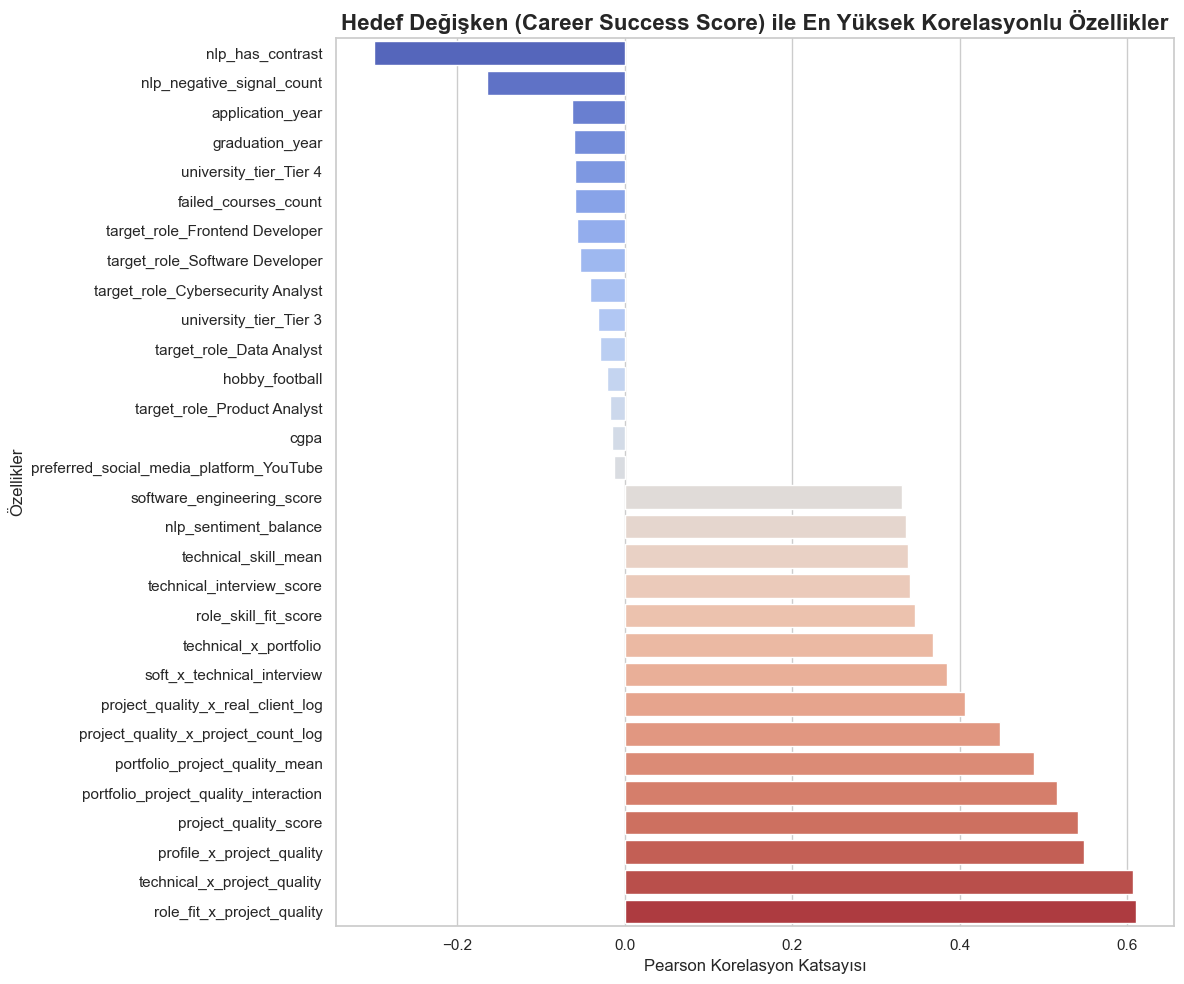


Birbiriyle %85'ten fazla korelasyonu olan 52 özellik bulundu. Kümeleme haritası çiziliyor...


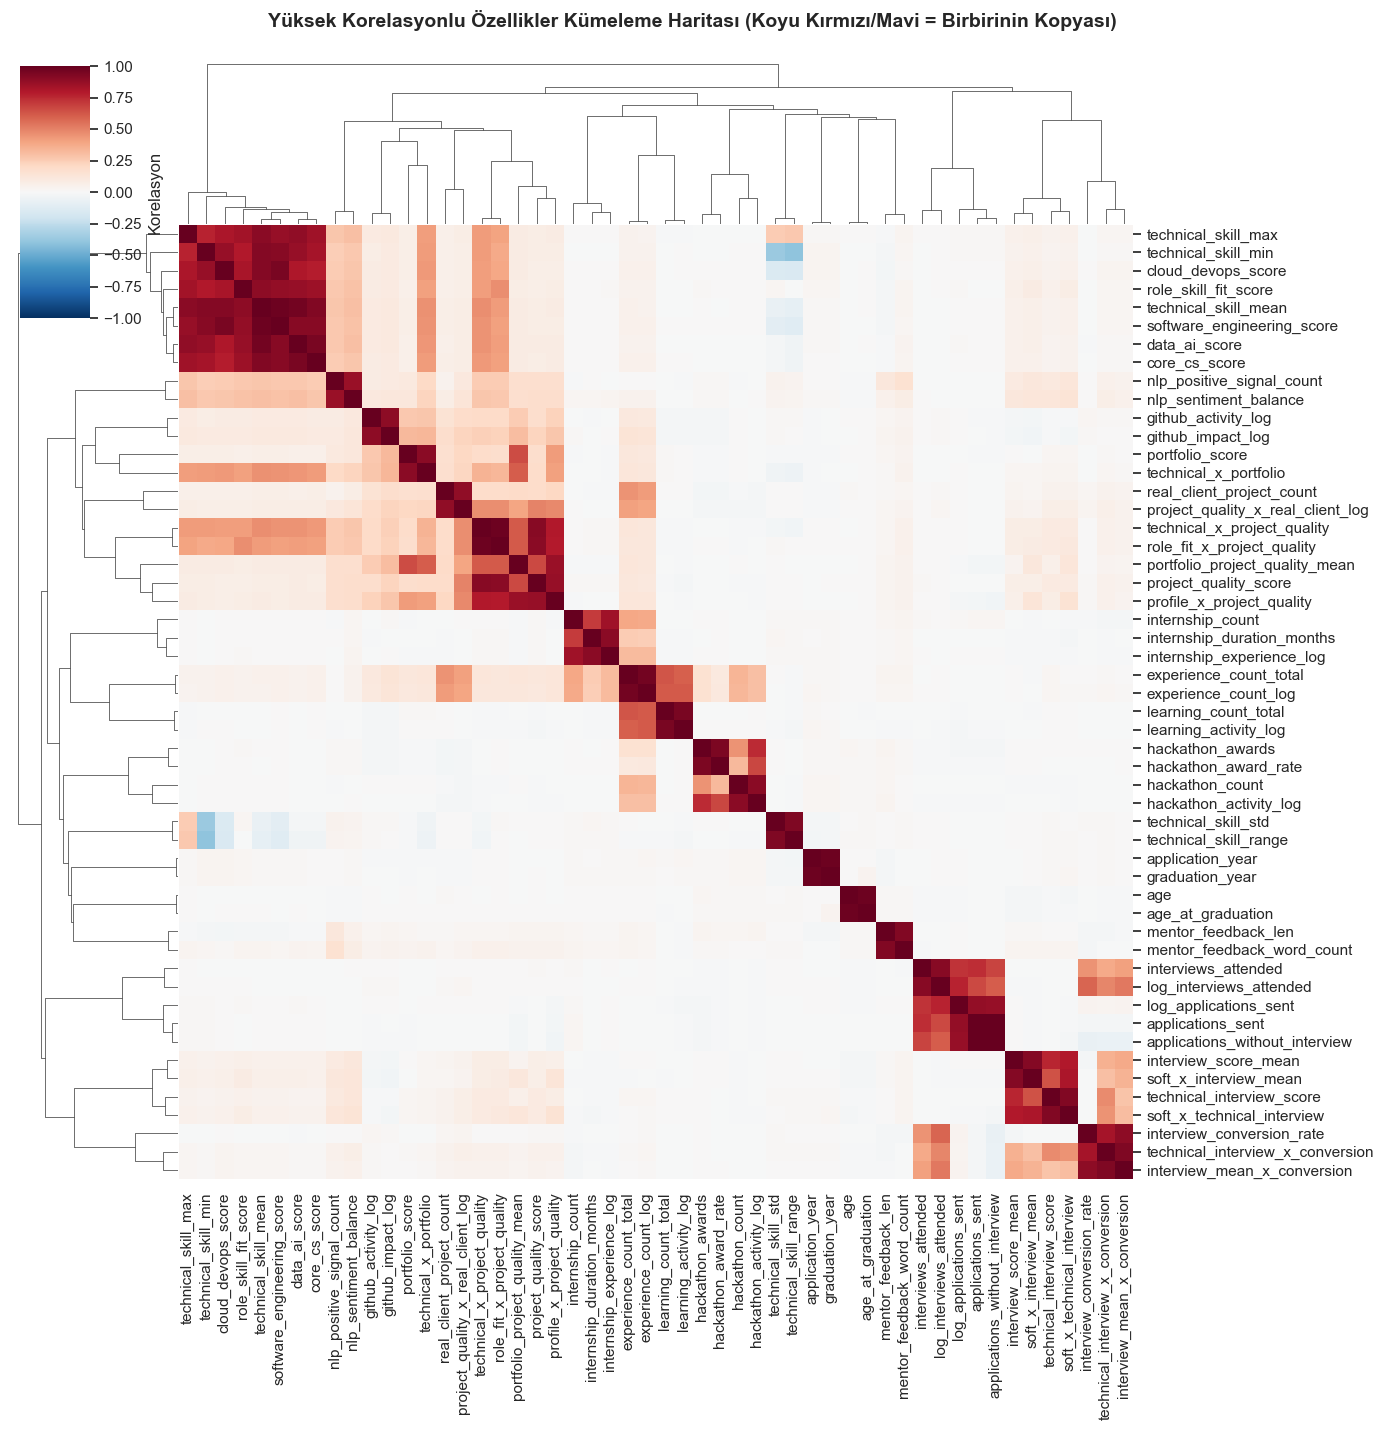


SİLİNMESİ GEREKEN TEHLİKELİ İKİLİLER (Korelasyon > %90)
🔹 applications_sent  <--->  applications_without_interview  (Korelasyon: 0.9969)
🔹 application_year  <--->  graduation_year  (Korelasyon: 0.9843)
🔹 technical_x_project_quality  <--->  role_fit_x_project_quality  (Korelasyon: 0.9804)
🔹 age  <--->  age_at_graduation  (Korelasyon: 0.9784)
🔹 technical_skill_mean  <--->  software_engineering_score  (Korelasyon: 0.9783)
🔹 experience_count_total  <--->  experience_count_log  (Korelasyon: 0.9676)
🔹 technical_skill_mean  <--->  data_ai_score  (Korelasyon: 0.9661)
🔹 data_ai_score  <--->  core_cs_score  (Korelasyon: 0.9525)
🔹 learning_count_total  <--->  learning_activity_log  (Korelasyon: 0.9522)
🔹 software_engineering_score  <--->  cloud_devops_score  (Korelasyon: 0.9454)
🔹 hackathon_awards  <--->  hackathon_award_rate  (Korelasyon: 0.9443)
🔹 technical_interview_x_conversion  <--->  interview_mean_x_conversion  (Korelasyon: 0.9316)
🔹 technical_skill_std  <--->  technical_skill_range  (Kor

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik stili ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Hedef değişkeni analiz için geçici olarak matrise ekleyelim
# (y_train'in indeks problemi yaratmaması için .values kullanıyoruz)
analysis_df = X_train_scaled_df.copy()
analysis_df['TARGET'] = y_train.values

print("İSTATİSTİKSEL DERİN ANALİZ BAŞLIYOR...\n" + "="*50)

# ==============================================================================
# 1. HEDEF DEĞİŞKENLE (TARGET) EN YÜKSEK KORELASYONA SAHİP ÖZELLİKLER
# Hangi özellikler başarı skorunu gerçekten etkiliyor?
# ==============================================================================
# Tüm kolonların Target ile korelasyonunu hesapla
target_corr = analysis_df.corr()['TARGET'].drop('TARGET').sort_values()

# En negatif 15 ve en pozitif 15 özelliği seç
top_features = pd.concat([target_corr.head(15), target_corr.tail(15)])

plt.figure(figsize=(12, 10))
sns.barplot(x=top_features.values, y=top_features.index, palette="coolwarm")
plt.title("Hedef Değişken (Career Success Score) ile En Yüksek Korelasyonlu Özellikler", fontsize=16, fontweight='bold')
plt.xlabel("Pearson Korelasyon Katsayısı")
plt.ylabel("Özellikler")
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. ÇOKLU BAĞLANTI (MULTICOLLINEARITY) KÜMELEME HARİTASI
# Hangi özellikler birbirinin kopyası? (144 kolonu çizmek karmaşık olacağı için 
# sadece birbiriyle >0.85 korelasyonu olan "tehlikeli" özellikleri çiziyoruz)
# ==============================================================================
corr_matrix = X_train_scaled_df.corr().abs()

# Köşegen (kendisiyle korelasyon) değerlerini 0 yapalım
np.fill_diagonal(corr_matrix.values, 0)

# Herhangi bir başka özellikle %85'ten fazla korelasyonu olan kolonları bul
high_corr_cols = corr_matrix.columns[(corr_matrix > 0.85).any()].tolist()

if len(high_corr_cols) > 0:
    print(f"\nBirbiriyle %85'ten fazla korelasyonu olan {len(high_corr_cols)} özellik bulundu. Kümeleme haritası çiziliyor...")
    high_corr_matrix = X_train_scaled_df[high_corr_cols].corr()
    
    # Clustermap: Birbirine çok benzeyen özellikleri yan yana gruplar (Dendrogram ile)
    sns.clustermap(high_corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, 
                   annot=False, figsize=(14, 14), 
                   cbar_kws={'label': 'Korelasyon'},
                   dendrogram_ratio=0.15)
    plt.suptitle("Yüksek Korelasyonlu Özellikler Kümeleme Haritası (Koyu Kırmızı/Mavi = Birbirinin Kopyası)", y=1.02, fontsize=14, fontweight='bold')
    plt.show()
else:
    print("\n%85'ten fazla korelasyona sahip özellik bulunamadı. Veriniz çok temiz!")

# ==============================================================================
# 3. İSTATİSTİKSEL ELEME RAPORU: "TEHLİKELİ İKİLİLER"
# ==============================================================================
print("\n" + "="*50)
print("SİLİNMESİ GEREKEN TEHLİKELİ İKİLİLER (Korelasyon > %90)")
print("="*50)

# Sadece üst üçgeni al (A-B ve B-A tekrarlarını önlemek için)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# %90'dan yüksek korelasyonu olan çiftleri bul
high_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        if upper_tri.loc[row, col] > 0.90:
            high_corr_pairs.append((row, col, upper_tri.loc[row, col]))

# Korelasyon büyüklüğüne göre sırala
high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

for pair in high_corr_pairs:
    print(f"🔹 {pair[0]}  <--->  {pair[1]}  (Korelasyon: {pair[2]:.4f})")
    
if not high_corr_pairs:
    print("Hiçbir tehlikeli ikili bulunamadı.")

In [14]:
# İstatistiksel analiz sonucunda modelin kafasını karıştıracak ve 
# birbirini tekrar eden (Korelasyon > %90) özelliklerin manuel listesi
manual_drop_cols = [
    "applications_without_interview", # applications_sent ile aynı
    "graduation_year",                # application_year ile aynı
    "technical_x_project_quality",    # role_fit_x_project_quality varken gereksiz
    "age_at_graduation",              # age varken gereksiz
    "experience_count_log",           # count (sayı) versiyonu var
    "learning_activity_log",          # count versiyonu var
    "log_interviews_attended",        # count versiyonu var
    "hackathon_activity_log",         # count versiyonu var
    "internship_experience_log",      # count/duration versiyonu var
    "mentor_feedback_len",            # word_count ile aynı
    "technical_skill_mean",           # role_skill_fit_score çok daha değerli!
    "soft_x_technical_interview",     # teknik mülakat skoru ile yüksek korele
    "soft_x_interview_mean",          # mülakat ortalaması ile yüksek korele
    "technical_skill_min",            # core_cs_score varken gereksiz
    "technical_skill_max",            # core_cs_score varken gereksiz
    "cloud_devops_score",             # software_engineering_score bunu kapsıyor
    "data_ai_score"                   # core_cs_score bunu kapsıyor
]

# Doğrudan SCALED (Ölçeklenmiş) veri setinden özellikleri düşürüyoruz
X_train_final = X_train_scaled_df.drop(columns=manual_drop_cols, errors='ignore')
X_test_final = X_test_scaled_df.drop(columns=manual_drop_cols, errors='ignore')

print(f"Manuel eleme sonrası EĞİTİM seti kolon sayısı: {X_train_final.shape[1]}")
print(f"Manuel eleme sonrası TEST seti kolon sayısı: {X_test_final.shape[1]}")

Manuel eleme sonrası EĞİTİM seti kolon sayısı: 127
Manuel eleme sonrası TEST seti kolon sayısı: 127


# **WITHOUT FEATURE IMPORTANCE**

# Step 4: TF-IDF
1. The texts will be digitized using TF-IDF.

2. A Ridge Regression model, a simple and fast model, will be trained to predict the target (achievement score) using only these words.

3. A text-based predictive score (text_model_pred) will be generated for each student without data leakage using K-Fold Cross Validation.

4. This number will be added as the 128th column to the 127-column X_train_final dataset.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np


In [16]:
# 1. Metinleri orjinal veri setinden çekiyoruz
train_text = train_df['mentor_feedback_text'].fillna("").astype(str)
test_text = test_df['mentor_feedback_text'].fillna("").astype(str)

print("🔍 Adım 1: En İyi TF-IDF ve Ridge Parametreleri Aranıyor...\n" + "-"*50)

# Kendi kendini optimize edecek Pipeline kurulumu
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('ridge', Ridge())
])

# Denenecek parametrelerin uzayı (Hem metin vektörelleştirici hem de model için)
param_distributions = {
    'tfidf__max_features': [5000, 10000, 15000, None], # En iyi kelime haznesi boyutu
    'tfidf__min_df': [2, 3, 5],                        # Çok nadir kelimeleri eleme sınırı
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],    # Sadece kelimeler mi, yoksa 2'li/3'lü kelime grupları mı?
    'ridge__alpha': [0.1, 1.0, 5.0, 10.0, 20.0]        # Ridge regülarizasyon (ceza) katsayısı
}

# RandomizedSearchCV: Tüm kombinasyonlar yerine rastgele en mantıklı 15 tanesini dener (Hız için)
search = RandomizedSearchCV(
    text_pipeline,
    param_distributions=param_distributions,
    n_iter=15,          # Denenecek kombinasyon sayısı (Süreyi kısaltmak için 15 yeterlidir)
    cv=3,               # 3'lü çapraz doğrulama ile test et
    scoring='neg_root_mean_squared_error', # Hedefimiz RMSE'yi düşürmek
    random_state=42,
    n_jobs=-1,          # İşlemi hızlandırmak için tüm işlemci çekirdeklerini kullan
    verbose=1
)

# Arama işlemini başlat
search.fit(train_text, y_train)

print("\n🏆 ŞAMPİYON PARAMETRELER BULUNDU!")
for param, value in search.best_params_.items():
    print(f" - {param}: {value}")
print(f"💡 Aramadaki En İyi Çapraz Doğrulama RMSE Skoru: {-search.best_score_:.4f}\n")

# ==============================================================================
# 2. BULUNAN EN İYİ AYARLARLA OOF (OUT-OF-FOLD) EĞİTİMİNE GEÇİŞ
# ==============================================================================
print("🚀 Adım 2: Bulunan Ayarlarla Sızıntısız OOF Eğitimi Başlıyor...\n" + "-"*50)

# Sözlükten tfidf ve ridge parametrelerini ayıklayıp otomatik atıyoruz
best_tfidf_params = {k.replace('tfidf__', ''): v for k, v in search.best_params_.items() if 'tfidf__' in k}
best_ridge_params = {k.replace('ridge__', ''): v for k, v in search.best_params_.items() if 'ridge__' in k}

# Modelleri en iyi ayarlarla baştan kuruyoruz
tfidf = TfidfVectorizer(**best_tfidf_params)
X_train_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_model = Ridge(**best_ridge_params)

oof_preds = np.zeros(len(train_text))
test_preds = np.zeros(len(test_text))

# Sızıntısız K-Fold Döngüsü
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_text)):
    X_tr, y_tr = X_train_text[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_text[val_idx], y_train.iloc[val_idx]
    
    ridge_model.fit(X_tr, y_tr)
    
    val_preds = ridge_model.predict(X_va)
    oof_preds[val_idx] = val_preds
    
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1} Tamamlandı - RMSE: {fold_rmse:.4f}")
    
    test_preds += ridge_model.predict(X_test_text) / kf.n_splits

# Sonuçları Kaydetme
oof_rmse = np.sqrt(mean_squared_error(y_train, oof_preds))
print("-" * 50)
print(f"🎯 GENEL NLP (OOF) RMSE SKORU: {oof_rmse:.4f}")

# Mucizevi NLP tahminimizi 128. kolon olarak ana verimize ekliyoruz
X_train_final['text_model_pred'] = oof_preds
X_test_final['text_model_pred'] = test_preds

print(f"\n✅ İşlem Tamam! Final EĞİTİM seti kolon sayısı: {X_train_final.shape[1]}")

🔍 Adım 1: En İyi TF-IDF ve Ridge Parametreleri Aranıyor...
--------------------------------------------------
Fitting 3 folds for each of 15 candidates, totalling 45 fits

🏆 ŞAMPİYON PARAMETRELER BULUNDU!
 - tfidf__ngram_range: (1, 3)
 - tfidf__min_df: 3
 - tfidf__max_features: None
 - ridge__alpha: 1.0
💡 Aramadaki En İyi Çapraz Doğrulama RMSE Skoru: 12.2625

🚀 Adım 2: Bulunan Ayarlarla Sızıntısız OOF Eğitimi Başlıyor...
--------------------------------------------------
Fold 1 Tamamlandı - RMSE: 12.4814
Fold 2 Tamamlandı - RMSE: 12.4304
Fold 3 Tamamlandı - RMSE: 12.1036
Fold 4 Tamamlandı - RMSE: 12.1165
Fold 5 Tamamlandı - RMSE: 12.3189
--------------------------------------------------
🎯 GENEL NLP (OOF) RMSE SKORU: 12.2911

✅ İşlem Tamam! Final EĞİTİM seti kolon sayısı: 128


# Step 5: Model Training with CatBoost

In [17]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

print("👑 BÜYÜK FİNAL: CatBoost Eğitimi Başlıyor...\n" + "="*50)

# CatBoost Parametreleri (Aşırı öğrenmeyi engellemek için özenle seçildi)
cb_params = {
    'iterations': 1500,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False # Ekranda çok fazla yazı çıkmaması için kapalı
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
final_oof_preds = np.zeros(len(X_train_final))
final_test_preds = np.zeros(len(X_test_final))

# Özellik önemlerini (Feature Importance) saklamak için
feature_importances = np.zeros(X_train_final.shape[1])

# 5-Fold Cross Validation ile CatBoost Eğitimi
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_final)):
    X_tr, y_tr = X_train_final.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_final.iloc[val_idx], y_train.iloc[val_idx]
    
    # Modeli Tanımla
    model = CatBoostRegressor(**cb_params)
    
    # Modeli Eğit (Erken durdurma - early stopping kullanarak)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        early_stopping_rounds=100,
        verbose=False
    )
    
    # Tahminleri Al
    val_preds = model.predict(X_va)
    final_oof_preds[val_idx] = val_preds
    
    # Test seti tahminlerini biriktir
    final_test_preds += model.predict(X_test_final) / kf.n_splits
    
    # Özellik önemlerini topla
    feature_importances += model.feature_importances_ / kf.n_splits
    
    # Fold başarısını ölç
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1} Bitti - CatBoost RMSE: {fold_rmse:.4f} (En iyi iterasyon: {model.get_best_iteration()})")

# Genel Başarı Skoru
final_rmse = np.sqrt(mean_squared_error(y_train, final_oof_preds))
print("="*50)
print(f"🚀 NİHAİ CATBOOST RMSE SKORUMUZ: {final_rmse:.4f}")

# ---------------------------------------------------------
# Hangi Özellikler Daha İşe Yaradı? (Feature Importance)
# ---------------------------------------------------------
fi_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\n🌟 Modele En Çok Katkı Sağlayan İlk 10 Özellik:")
display(fi_df.head(10))

# ---------------------------------------------------------
# Submission Dosyasını Oluşturma
# ---------------------------------------------------------
submission = pd.DataFrame({
    'student_id': test_df['student_id'],
    'career_success_score': final_test_preds
})

submission.to_csv("FINAL_catboost_submission.csv", index=False)
print("\n✅ 'FINAL_catboost_submission.csv' dosyası başarıyla kaydedildi! Artık Kaggle'a yükleyebilirsiniz.")

👑 BÜYÜK FİNAL: CatBoost Eğitimi Başlıyor...
Fold 1 Bitti - CatBoost RMSE: 8.8749 (En iyi iterasyon: 639)
Fold 2 Bitti - CatBoost RMSE: 9.1299 (En iyi iterasyon: 546)
Fold 3 Bitti - CatBoost RMSE: 8.4897 (En iyi iterasyon: 626)
Fold 4 Bitti - CatBoost RMSE: 8.5261 (En iyi iterasyon: 592)
Fold 5 Bitti - CatBoost RMSE: 8.9028 (En iyi iterasyon: 734)
🚀 NİHAİ CATBOOST RMSE SKORUMUZ: 8.7880

🌟 Modele En Çok Katkı Sağlayan İlk 10 Özellik:


,Feature,Importance
127,text_model_pred,11.606329
82,role_fit_x_project_quality,10.159646
28,technical_interview_score,8.104039
15,project_quality_score,5.023173
0,application_year,4.344399
30,communication_score,3.101162
83,profile_x_project_quality,2.939886
77,interview_score_mean,2.561298
57,soft_skill_mean,2.385797
63,project_quality_x_real_client_log,1.938899



✅ 'FINAL_catboost_submission.csv' dosyası başarıyla kaydedildi! Artık Kaggle'a yükleyebilirsiniz.


In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

print("👑 BÜYÜK FİNAL: CatBoost Eğitimi Başlıyor...\n" + "="*50)

# CatBoost Parametreleri (Aşırı öğrenmeyi engellemek için özenle seçildi)
cb_params = {
    'iterations': 1500,
    'learning_rate': 0.025,
    'depth': 6,
    'l2_leaf_reg': 3,
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False # Ekranda çok fazla yazı çıkmaması için kapalı
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
final_oof_preds = np.zeros(len(X_train_final))
final_test_preds = np.zeros(len(X_test_final))

# Özellik önemlerini (Feature Importance) saklamak için
feature_importances = np.zeros(X_train_final.shape[1])

# 5-Fold Cross Validation ile CatBoost Eğitimi
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_final)):
    X_tr, y_tr = X_train_final.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_final.iloc[val_idx], y_train.iloc[val_idx]
    
    # Modeli Tanımla
    model = CatBoostRegressor(**cb_params)
    
    # Modeli Eğit (Erken durdurma - early stopping kullanarak)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        early_stopping_rounds=100,
        verbose=False
    )
    
    # Tahminleri Al
    val_preds = model.predict(X_va)
    final_oof_preds[val_idx] = val_preds
    
    # Test seti tahminlerini biriktir
    final_test_preds += model.predict(X_test_final) / kf.n_splits
    
    # Özellik önemlerini topla
    feature_importances += model.feature_importances_ / kf.n_splits
    
    # Fold başarısını ölç
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1} Bitti - CatBoost RMSE: {fold_rmse:.4f} (En iyi iterasyon: {model.get_best_iteration()})")

# Genel Başarı Skoru
final_rmse = np.sqrt(mean_squared_error(y_train, final_oof_preds))
print("="*50)
print(f"🚀 NİHAİ CATBOOST RMSE SKORUMUZ: {final_rmse:.4f}")

# ---------------------------------------------------------
# Hangi Özellikler Daha İşe Yaradı? (Feature Importance)
# ---------------------------------------------------------
fi_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("\n🌟 Modele En Çok Katkı Sağlayan İlk 10 Özellik:")
display(fi_df.head(10))

# ---------------------------------------------------------
# Submission Dosyasını Oluşturma
# ---------------------------------------------------------
submission = pd.DataFrame({
    'student_id': test_df['student_id'],
    'career_success_score': final_test_preds
})

submission.to_csv("FINAL_catboost_submission_lr03.csv", index=False)
print("\n✅ 'FINAL_catboost_submission.csv' dosyası başarıyla kaydedildi! Artık Kaggle'a yükleyebilirsiniz.")

👑 BÜYÜK FİNAL: CatBoost Eğitimi Başlıyor...
Fold 1 Bitti - CatBoost RMSE: 8.8552 (En iyi iterasyon: 1191)
Fold 2 Bitti - CatBoost RMSE: 9.0932 (En iyi iterasyon: 1492)
Fold 3 Bitti - CatBoost RMSE: 8.4894 (En iyi iterasyon: 1336)
Fold 4 Bitti - CatBoost RMSE: 8.5585 (En iyi iterasyon: 1493)
Fold 5 Bitti - CatBoost RMSE: 8.9284 (En iyi iterasyon: 1499)
🚀 NİHAİ CATBOOST RMSE SKORUMUZ: 8.7879

🌟 Modele En Çok Katkı Sağlayan İlk 10 Özellik:


,Feature,Importance
127,text_model_pred,11.359686
82,role_fit_x_project_quality,10.124072
28,technical_interview_score,7.947138
15,project_quality_score,5.348491
0,application_year,4.337336
30,communication_score,3.090371
77,interview_score_mean,2.590342
83,profile_x_project_quality,2.583518
57,soft_skill_mean,2.419125
63,project_quality_x_real_client_log,1.964715



✅ 'FINAL_catboost_submission.csv' dosyası başarıyla kaydedildi! Artık Kaggle'a yükleyebilirsiniz.


# Feature Importance Calculation with SHAP and Permutation Importance

- SHAP calculates how and by what extent a feature affects an outcome.
- After the model is trained, it sequentially shuffles the values ​​in each column randomly. If shuffling a column causes the model's RMSE score to plummet, then that column is truly important. If the RMSE doesn't change, then that column is useless.


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.1 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Us

AttributeError: _ARRAY_API not found

c:\Users\busra\anaconda3\envs\gykml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔬 DERİN ÖZELLİK ANALİZİ BAŞLIYOR...
1. SHAP Değerleri Hesaplanıyor (Bu işlem 1-2 dakika sürebilir)...


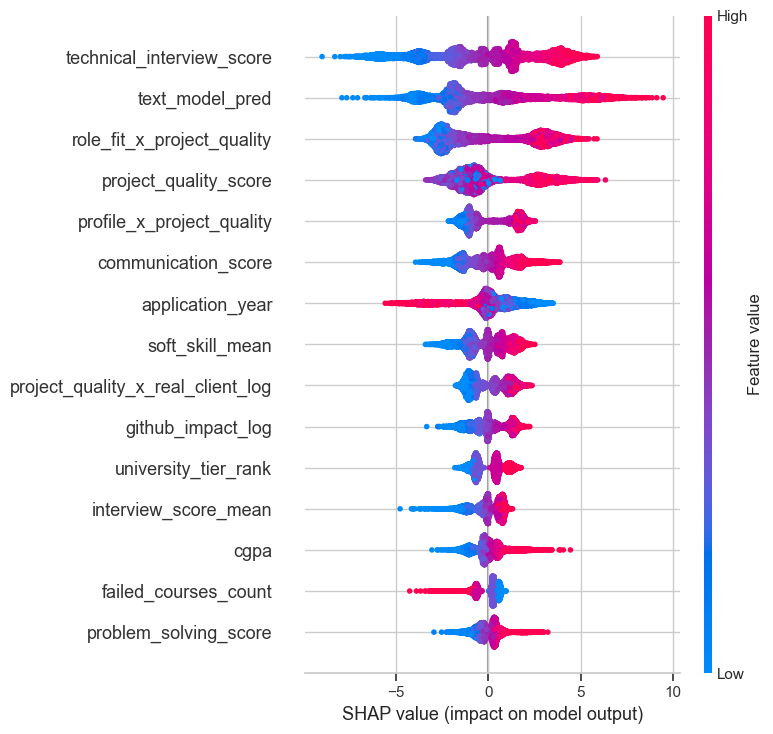


2. Permutation (Karıştırma) Analizi Yapılıyor...

🌟 SHAP'E GÖRE EN GÜÇLÜ İLK 10 ÖZELLİK:


,Feature,SHAP_Importance
28,technical_interview_score,2.544196
127,text_model_pred,2.519959
82,role_fit_x_project_quality,2.345289
15,project_quality_score,1.613272
83,profile_x_project_quality,1.247737
30,communication_score,1.143165
0,application_year,1.112247
57,soft_skill_mean,0.984821
63,project_quality_x_real_client_log,0.950982
66,github_impact_log,0.825502



🌟 PERMUTASYON'A (Karıştırmaya) GÖRE EN GÜÇLÜ İLK 10 ÖZELLİK:


,Feature,RMSE_Drop
28,technical_interview_score,1.497700
127,text_model_pred,1.478147
82,role_fit_x_project_quality,1.375309
15,project_quality_score,1.015712
0,application_year,0.875015
30,communication_score,0.540948
2,cgpa,0.375335
57,soft_skill_mean,0.336511
66,github_impact_log,0.284397
83,profile_x_project_quality,0.273664


--------------------------------------------------
⚠️ Her iki teste göre de modele HİÇBİR faydası olmayan özellik sayısı: 4


In [23]:
import shap
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
from catboost import CatBoostRegressor

print("🔬 DERİN ÖZELLİK ANALİZİ BAŞLIYOR...\n" + "="*50)

# Tüm veriyi (128 kolon) görebilmesi için ana bir model eğitiyoruz
final_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, verbose=False, random_seed=42)
final_model.fit(X_train_final, y_train)

# ==============================================================================
# YÖNTEM 1: SHAP (SHapley Additive exPlanations)
# ==============================================================================
print("1. SHAP Değerleri Hesaplanıyor (Bu işlem 1-2 dakika sürebilir)...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_train_final)

# Göz alıcı SHAP Grafiğini çizdiriyoruz
shap.summary_plot(shap_values, X_train_final, max_display=15)

# SHAP Değerlerini sayısal bir tabloya çevirelim
shap_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'SHAP_Importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='SHAP_Importance', ascending=False)

# ==============================================================================
# YÖNTEM 2: PERMUTATION IMPORTANCE (RMSE Etkisi)
# ==============================================================================
print("\n2. Permutation (Karıştırma) Analizi Yapılıyor...")
# İşlemi hızlandırmak için eğitim setinden rastgele 2000 satır seçiyoruz
sample_idx = np.random.choice(X_train_final.index, size=2000, replace=False)
X_sample = X_train_final.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

# Kolonları karıştırıp RMSE'nin ne kadar bozulduğuna bakıyoruz
perm_importance = permutation_importance(
    final_model, X_sample, y_sample, 
    n_repeats=5, random_state=42, scoring='neg_root_mean_squared_error'
)

perm_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'RMSE_Drop': perm_importance.importances_mean # Pozitif değerler RMSE'yi bozan (önemli) kolonlardır
}).sort_values(by='RMSE_Drop', ascending=False)

# ==============================================================================
# SONUÇLARI GÖRÜNTÜLEME
# ==============================================================================
print("\n🌟 SHAP'E GÖRE EN GÜÇLÜ İLK 10 ÖZELLİK:")
display(shap_df.head(10))

print("\n🌟 PERMUTASYON'A (Karıştırmaya) GÖRE EN GÜÇLÜ İLK 10 ÖZELLİK:")
display(perm_df.head(10))

# Budama için fikir verme
zero_shap = shap_df[shap_df['SHAP_Importance'] <= 0.005]['Feature'].tolist()
zero_perm = perm_df[perm_df['RMSE_Drop'] <= 0.0]['Feature'].tolist()
ortak_copler = list(set(zero_shap).intersection(set(zero_perm)))

print("-" * 50)
print(f"⚠️ Her iki teste göre de modele HİÇBİR faydası olmayan özellik sayısı: {len(ortak_copler)}")

In [24]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

print("✂️ NİHAİ BUDAMA VE ŞAMPİYON MODEL EĞİTİMİ BAŞLIYOR...\n" + "="*50)

# 1. Zararlı ve Etkisiz Özellikleri Belirleme
# Hem ortak çöpleri alıyoruz hem de Permütasyon skoru 0'ın altında olanları (modele zarar verenleri) alıyoruz
bad_features = list(set(ortak_copler).union(set(perm_df[perm_df['RMSE_Drop'] < 0]['Feature'].tolist())))

print(f"Toplam silinecek zararlı/etkisiz özellik sayısı: {len(bad_features)}")
print(f"Silinen Özellikler: {bad_features}\n")

# 2. Veri Setini Son Kez Budama
X_train_elite = X_train_final.drop(columns=bad_features, errors='ignore')
X_test_elite = X_test_final.drop(columns=bad_features, errors='ignore')

print(f"Kalan 'Elit' Özellik Sayısı: {X_train_elite.shape[1]}")
print("-" * 50)



✂️ NİHAİ BUDAMA VE ŞAMPİYON MODEL EĞİTİMİ BAŞLIYOR...
Toplam silinecek zararlı/etkisiz özellik sayısı: 4
Silinen Özellikler: ['hobby_music', 'hobby_cinema', 'target_role_Product Analyst', 'department_Electrical Electronics Engineering']

Kalan 'Elit' Özellik Sayısı: 124
--------------------------------------------------


# CatBoost Training with Feature Importance

In [25]:
# 3. CatBoost Eğitimi
cb_params = {
    'iterations': 1500,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False 
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
elite_oof_preds = np.zeros(len(X_train_elite))
elite_test_preds = np.zeros(len(X_test_elite))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_elite)):
    X_tr, y_tr = X_train_elite.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_elite.iloc[val_idx], y_train.iloc[val_idx]
    
    model = CatBoostRegressor(**cb_params)
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100, verbose=False)
    
    val_preds = model.predict(X_va)
    elite_oof_preds[val_idx] = val_preds
    elite_test_preds += model.predict(X_test_elite) / kf.n_splits
    
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1} (Elit Veri) - RMSE: {fold_rmse:.4f}")

# Yeni RMSE Skoru
elite_rmse = np.sqrt(mean_squared_error(y_train, elite_oof_preds))
print("="*50)
print(f"🚀 NİHAİ (ELİT) CATBOOST RMSE SKORUMUZ: {elite_rmse:.4f}")

# Kaggle Submission Dosyası
submission_elite = pd.DataFrame({
    'student_id': test_df['student_id'],
    'career_success_score': elite_test_preds
})

# Çıktı dosyasını kaydediyoruz
file_name = "FINAL_Kaggle_Submission.csv"
submission_elite.to_csv(file_name, index=False)
print(f"\n✅ '{file_name}' dosyası başarıyla kaydedildi! Kaggle'a yüklemeye hazır.")

Fold 1 (Elit Veri) - RMSE: 8.8984
Fold 2 (Elit Veri) - RMSE: 9.1025
Fold 3 (Elit Veri) - RMSE: 8.4642
Fold 4 (Elit Veri) - RMSE: 8.5763
Fold 5 (Elit Veri) - RMSE: 8.9312
🚀 NİHAİ (ELİT) CATBOOST RMSE SKORUMUZ: 8.7977

✅ 'FINAL_Kaggle_Submission.csv' dosyası başarıyla kaydedildi! Kaggle'a yüklemeye hazır.


# LightGBM training with cleaned data

In [27]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

print("⚡ YENİ MODEL: LightGBM Eğitimi Başlıyor...\n" + "="*50)

# LightGBM Parametreleri
lgbm_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,           # Yaprak sayısı (LightGBM için çok kritik)
    'feature_fraction': 0.8,    # Her ağaçta kolonların %80'ini kullan (Gürültüyü engeller)
    'bagging_fraction': 0.8,    # Satırların %80'ini kullan (Overfitting'i engeller)
    'bagging_freq': 1,
    'verbose': -1,              # Uyarıları gizle
    'random_state': 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lgbm_oof_preds = np.zeros(len(X_train_elite))
lgbm_test_preds = np.zeros(len(X_test_elite))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_elite)):
    X_tr, y_tr = X_train_elite.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_elite.iloc[val_idx], y_train.iloc[val_idx]
    
    # LGBM veri yapısı
    dtrain = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_va, label=y_va, reference=dtrain)
    
    # Modeli Eğit (Early stopping v2.0 ile)
    model = lgb.train(
        lgbm_params,
        dtrain,
        num_boost_round=1500,
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    # Tahminler
    val_preds = model.predict(X_va, num_iteration=model.best_iteration)
    lgbm_oof_preds[val_idx] = val_preds
    lgbm_test_preds += model.predict(X_test_elite, num_iteration=model.best_iteration) / kf.n_splits
    
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1} (LightGBM) - RMSE: {fold_rmse:.4f} (İterasyon: {model.best_iteration})")

# Yeni LightGBM RMSE Skoru
lgbm_rmse = np.sqrt(mean_squared_error(y_train, lgbm_oof_preds))
print("="*50)
print(f"🚀 LİGHTGBM NİHAİ RMSE SKORUMUZ: {lgbm_rmse:.4f}")

# Submission Dosyası
submission_lgbm = pd.DataFrame({
    'student_id': test_df['student_id'],
    'career_success_score': lgbm_test_preds
})

submission_lgbm.to_csv("FINAL_LightGBM_Submission.csv", index=False)

⚡ YENİ MODEL: LightGBM Eğitimi Başlıyor...
Fold 1 (LightGBM) - RMSE: 9.0108 (İterasyon: 254)
Fold 2 (LightGBM) - RMSE: 9.2366 (İterasyon: 249)
Fold 3 (LightGBM) - RMSE: 8.6530 (İterasyon: 322)
Fold 4 (LightGBM) - RMSE: 8.7142 (İterasyon: 285)
Fold 5 (LightGBM) - RMSE: 9.0450 (İterasyon: 370)
🚀 LİGHTGBM NİHAİ RMSE SKORUMUZ: 8.9346


# CatBoost Training with k_fold=10

In [31]:
# 3. CatBoost Eğitimi
cb_params = {
    'iterations': 5000,
    'learning_rate': 0.03,
    'depth': 6,
    'l2_leaf_reg': 3,
    'eval_metric': 'RMSE',
    'random_seed': 42,
    'verbose': False 
}

kf = KFold(n_splits=8, shuffle=True, random_state=42)
elite_oof_preds = np.zeros(len(X_train_elite))
elite_test_preds = np.zeros(len(X_test_elite))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_elite)):
    X_tr, y_tr = X_train_elite.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_elite.iloc[val_idx], y_train.iloc[val_idx]
    
    model = CatBoostRegressor(**cb_params)
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100, verbose=False)
    
    val_preds = model.predict(X_va)
    elite_oof_preds[val_idx] = val_preds
    elite_test_preds += model.predict(X_test_elite) / kf.n_splits
    
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1} - RMSE: {fold_rmse:.4f}")

# Yeni RMSE Skoru
elite_rmse = np.sqrt(mean_squared_error(y_train, elite_oof_preds))
print("="*50)
print(f"🚀 NİHAİ CATBOOST RMSE SKORU: {elite_rmse:.4f}")

# Kaggle Submission Dosyası
submission_elite = pd.DataFrame({
    'student_id': test_df['student_id'],
    'career_success_score': elite_test_preds
})

# Çıktı dosyasını kaydediyoruz
file_name = "FINAL_Kaggle_Submission.csv"
submission_elite.to_csv(file_name, index=False)
print(f"\n✅ '{file_name}' dosyası başarıyla kaydedildi! Kaggle'a yüklemeye hazır.")

Fold 1 - RMSE: 8.7045
Fold 2 - RMSE: 9.1246
Fold 3 - RMSE: 9.0485
Fold 4 - RMSE: 8.6421
Fold 5 - RMSE: 8.4311
Fold 6 - RMSE: 8.4918
Fold 7 - RMSE: 8.7552
Fold 8 - RMSE: 8.9435
🚀 NİHAİ CATBOOST RMSE SKORU: 8.7708

✅ 'FINAL_Kaggle_Submission.csv' dosyası başarıyla kaydedildi! Kaggle'a yüklemeye hazır.


# XGBoost Training

In [36]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

print("XGBoost 10-Fold Eğitimi Başlıyor...\n" + "="*50)

# XGBoost Parametreleri 
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,           
    'colsample_bytree': 0.8,    
    'random_state': 42,
    'n_jobs': -1                
}

# 10-FOLD CROSS VALIDATION
kf = KFold(n_splits=10, shuffle=True, random_state=42)

xgb_oof_preds = np.zeros(len(X_train_elite))
xgb_test_preds = np.zeros(len(X_test_elite))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_elite)):
    X_tr, y_tr = X_train_elite.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_elite.iloc[val_idx], y_train.iloc[val_idx]
    
    # DÜZELTME BURADA: early_stopping_rounds artık model tanımlanırken veriliyor
    model = xgb.XGBRegressor(
        n_estimators=1500, 
        early_stopping_rounds=100, 
        **xgb_params
    )
    
    # Modeli Eğitme (early_stopping_rounds buradan silindi)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )
    
    # Tahminleri Al
    val_preds = model.predict(X_va)
    xgb_oof_preds[val_idx] = val_preds
    
    # Test verisini tahmin et ve 10'a bölerek ortalamaya ekle
    xgb_test_preds += model.predict(X_test_elite) / kf.n_splits
    
    # Fold başarısını ölç
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1:02d} Tamamlandı - XGBoost RMSE: {fold_rmse:.4f} (İterasyon: {model.best_iteration})")

# Yeni RMSE Skoru
xgb_rmse = np.sqrt(mean_squared_error(y_train, xgb_oof_preds))
print("="*50)
print(f" XGBOOST NİHAİ RMSE SKORU: {xgb_rmse:.4f}")

# Kaggle Submission Dosyası
submission_xgb = pd.DataFrame({
    'student_id': test_df['student_id'],
    'career_success_score': xgb_test_preds
})

file_name = "FINAL_10Fold_XGBoost_Submission.csv"
submission_xgb.to_csv(file_name, index=False)
print(f"\n✅ '{file_name}' dosyası başarıyla kaydedildi!")

XGBoost 10-Fold Eğitimi Başlıyor...
Fold 01 Tamamlandı - XGBoost RMSE: 8.7795 (İterasyon: 207)
Fold 02 Tamamlandı - XGBoost RMSE: 9.3593 (İterasyon: 226)
Fold 03 Tamamlandı - XGBoost RMSE: 9.0813 (İterasyon: 231)
Fold 04 Tamamlandı - XGBoost RMSE: 9.5803 (İterasyon: 214)
Fold 05 Tamamlandı - XGBoost RMSE: 8.7627 (İterasyon: 252)
Fold 06 Tamamlandı - XGBoost RMSE: 8.5726 (İterasyon: 252)
Fold 07 Tamamlandı - XGBoost RMSE: 8.8652 (İterasyon: 254)
Fold 08 Tamamlandı - XGBoost RMSE: 8.6675 (İterasyon: 218)
Fold 09 Tamamlandı - XGBoost RMSE: 8.9787 (İterasyon: 574)
Fold 10 Tamamlandı - XGBoost RMSE: 9.0278 (İterasyon: 261)
 XGBOOST NİHAİ RMSE SKORU: 8.9724

✅ 'FINAL_10Fold_XGBoost_Submission.csv' dosyası başarıyla kaydedildi!


# Ensemble Model

In [39]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

print("🧩 KAGGLE ŞAMPİYON TAKTİĞİ: STACKING (HARMANLAMA) BAŞLIYOR...\n" + "="*50)

# 1. Temel Modelleri (Base Learners) Tanımlıyoruz
# CatBoost ve LGBM'in en güvendiğimiz, stabil ayarlarını kullanıyoruz
cat_model = CatBoostRegressor(
    iterations=1500, learning_rate=0.05, depth=6, 
    l2_leaf_reg=3, verbose=False, random_seed=42
)

lgbm_model = LGBMRegressor(
    n_estimators=1500, learning_rate=0.03, max_depth=6, 
    num_leaves=31, subsample=0.8, colsample_bytree=0.8, 
    verbose=-1, random_state=42
)

# 2. Stacking Mimarisini Kuruyoruz
# Temel modellerin tahminlerini birleştirecek Meta-Model: Ridge Regresyonu
stacked_model = StackingRegressor(
    estimators=[
        ('cat', cat_model),
        ('lgbm', lgbm_model)
    ],
    final_estimator=Ridge(alpha=10.0), # Aşırı öğrenmeyi engelleyen mantıklı bir hakem
    cv=5, # Stacking kendi içinde sızıntıyı önlemek için 5-fold kullanır
    n_jobs=-1
)

# 3. 5-Fold ile OOF (Out-of-Fold) Tahminleri ve Değerlendirme
kf = KFold(n_splits=5, shuffle=True, random_state=42)

stack_oof_preds = np.zeros(len(X_train_elite))
stack_test_preds = np.zeros(len(X_test_elite))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_elite)):
    X_tr, y_tr = X_train_elite.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train_elite.iloc[val_idx], y_train.iloc[val_idx]
    
    # Stacking Modelini Eğit
    stacked_model.fit(X_tr, y_tr)
    
    # Tahminleri Al
    val_preds = stacked_model.predict(X_va)
    stack_oof_preds[val_idx] = val_preds
    
    # Test verisini tahmin et
    stack_test_preds += stacked_model.predict(X_test_elite) / kf.n_splits
    
    fold_rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold+1} Tamamlandı - Stacking RMSE: {fold_rmse:.4f}")

# Nihai Stacking Skoru
stack_rmse = np.sqrt(mean_squared_error(y_train, stack_oof_preds))
print("="*50)
print(f"🚀 NİHAİ STACKING (CATBOOST + LGBM) RMSE SKORUMUZ: {stack_rmse:.4f}")

# Submission Dosyası
submission_stack = pd.DataFrame({
    'student_id': test_df['student_id'],
    'career_success_score': stack_test_preds
})

file_name = "FINAL_Stacking_Submission.csv"
submission_stack.to_csv(file_name, index=False)
print(f"\n✅ '{file_name}' dosyası başarıyla kaydedildi!")

🧩 KAGGLE ŞAMPİYON TAKTİĞİ: STACKING (HARMANLAMA) BAŞLIYOR...
Fold 1 Tamamlandı - Stacking RMSE: 8.9615
Fold 2 Tamamlandı - Stacking RMSE: 9.1305
Fold 3 Tamamlandı - Stacking RMSE: 8.4917
Fold 4 Tamamlandı - Stacking RMSE: 8.6099
Fold 5 Tamamlandı - Stacking RMSE: 8.9161
🚀 NİHAİ STACKING (CATBOOST + LGBM) RMSE SKORUMUZ: 8.8251

✅ 'FINAL_Stacking_Submission.csv' dosyası başarıyla kaydedildi!
